# Seismic Data Analysis: Part 1: Exploration & Preprocessing

This notebook covers the full data pipeline for the Moroccan earthquake dataset (1901–2023), collected in collaboration with the **Institut National de Géophysique (ING)**. It includes:

- Data loading and quality audit
- Cleaning and validation (corrupt coordinates, future-dated records, invalid magnitudes)
- Temporal and spatial exploratory analysis
- Feature engineering for downstream ML tasks

The cleaned dataset produced here is used directly in `02_model_comparison.ipynb`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

DATA_PATH = '../data/cleaned_earthquake_data.csv'
FIGURES   = '../figures/'

Matplotlib is building the font cache; this may take a moment.


## 1. Load Data

In [2]:
df_raw = pd.read_csv(DATA_PATH)
df_raw['DateTime'] = pd.to_datetime(df_raw['DateTime'])
print(f'Raw dataset: {df_raw.shape[0]:,} records, {df_raw.shape[1]} columns')
df_raw.head()

Raw dataset: 65,931 records, 13 columns


,date,time,latitude,longitude,depth,mag,year,month,day,hour,minute,second,DateTime
0,1901-04-24,15:45:00,36.83,-7.67,0.0,0.0,1901,4,24,15,45,0,1901-04-24 15:45:00
1,1901-05-25,03:25:00,36.70,-3.50,0.0,5.0,1901,5,25,3,25,0,1901-05-25 03:25:00
2,1901-12-10,00:00:00,36.42,-5.24,0.0,5.0,1901,12,10,0,0,0,1901-12-10 00:00:00
3,1902-05-01,12:38:00,35.20,-4.10,0.0,4.2,1902,5,1,12,38,0,1902-05-01 12:38:00
4,1902-06-16,13:30:00,35.30,-3.00,0.0,0.0,1902,6,16,13,30,0,1902-06-16 13:30:00


## 2. Quality Audit

Before cleaning, we document every data quality issue present in the raw dataset.

In [3]:
issues = {
    'Missing latitude':           df_raw['latitude'].isna().sum(),
    'Missing longitude':          df_raw['longitude'].isna().sum(),
    'Missing magnitude':          df_raw['mag'].isna().sum(),
    'Corrupt longitude (<-180)':  (df_raw['longitude'] < -180).sum(),
    'Invalid magnitude (<0)':     (df_raw['mag'] < 0).sum(),
    'Future-dated records (>2023)':(df_raw['year'] > 2023).sum(),
    'Depth outliers (>2000 km)':  (df_raw['depth'] > 2000).sum(),
}
audit = pd.DataFrame.from_dict(issues, orient='index', columns=['Count'])
audit['% of dataset'] = (audit['Count'] / len(df_raw) * 100).round(3)
print(audit.to_string())

                              Count  % of dataset
Missing latitude                 10         0.015
Missing longitude                 0         0.000
Missing magnitude                 0         0.000
Corrupt longitude (<-180)         2         0.003
Invalid magnitude (<0)          338         0.513
Future-dated records (>2023)      1         0.002
Depth outliers (>2000 km)         2         0.003


## 3. Data Cleaning

We apply the following filters in order:
1. Remove rows with corrupt geographic coordinates (2 rows with longitude = −571 and −4,251)
2. Remove 1 future-dated record (year = 2110, likely a transcription error)
3. Remove records with negative magnitudes (sensor noise / catalog errors)
4. Remove depth outliers beyond physically plausible range
5. Drop remaining rows with missing core fields

In [4]:
df = df_raw.copy()

df = df[df['longitude'].between(-180, 180)]      # corrupt coordinates
df = df[df['latitude'].between(-90, 90)]
df = df[df['year'] <= 2023]                       # future-dated record
df = df[df['mag'] >= 0]                           # invalid magnitudes
df = df[df['depth'] <= 2000]                      # depth outliers
df = df.dropna(subset=['latitude', 'longitude', 'mag'])
df = df.reset_index(drop=True)

removed = len(df_raw) - len(df)
print(f'Removed {removed} records ({removed/len(df_raw)*100:.2f}%)')
print(f'Clean dataset: {len(df):,} records')
df.describe().round(3)

Removed 353 records (0.54%)
Clean dataset: 65,578 records


,latitude,longitude,depth,mag,year,month,day,hour,minute,second,DateTime
count,65578.000,65578.000,65578.000,65578.000,65578.000,65578.000,65578.000,65578.000,65578.000,65578.000,65578
mean,34.528,-5.043,21.922,1.761,2012.157,6.452,3.737,11.448,29.513,29.313,2012-08-26 04:04:34.331605
min,0.000,-162.000,0.000,0.000,1901.000,1.000,0.000,0.000,0.000,0.000,1901-04-24 15:45:00
25%,33.513,-6.309,6.800,1.200,2015.000,4.000,0.000,5.000,15.000,14.000,2015-06-01 22:43:29.250000
50%,35.387,-3.807,14.600,1.700,2019.000,7.000,0.000,12.000,30.000,29.000,2019-11-18 06:24:26.500000
75%,35.617,-3.574,26.600,2.400,2022.000,9.000,0.000,18.000,44.000,44.000,2022-04-24 07:34:48.750000
max,43.320,7.648,1410.400,7.300,2023.000,12.000,31.000,23.000,59.000,59.000,2023-10-22 22:27:11
std,1.861,2.500,39.529,1.024,17.199,3.323,8.026,7.035,17.305,17.454,NaN


## 4. Temporal Analysis

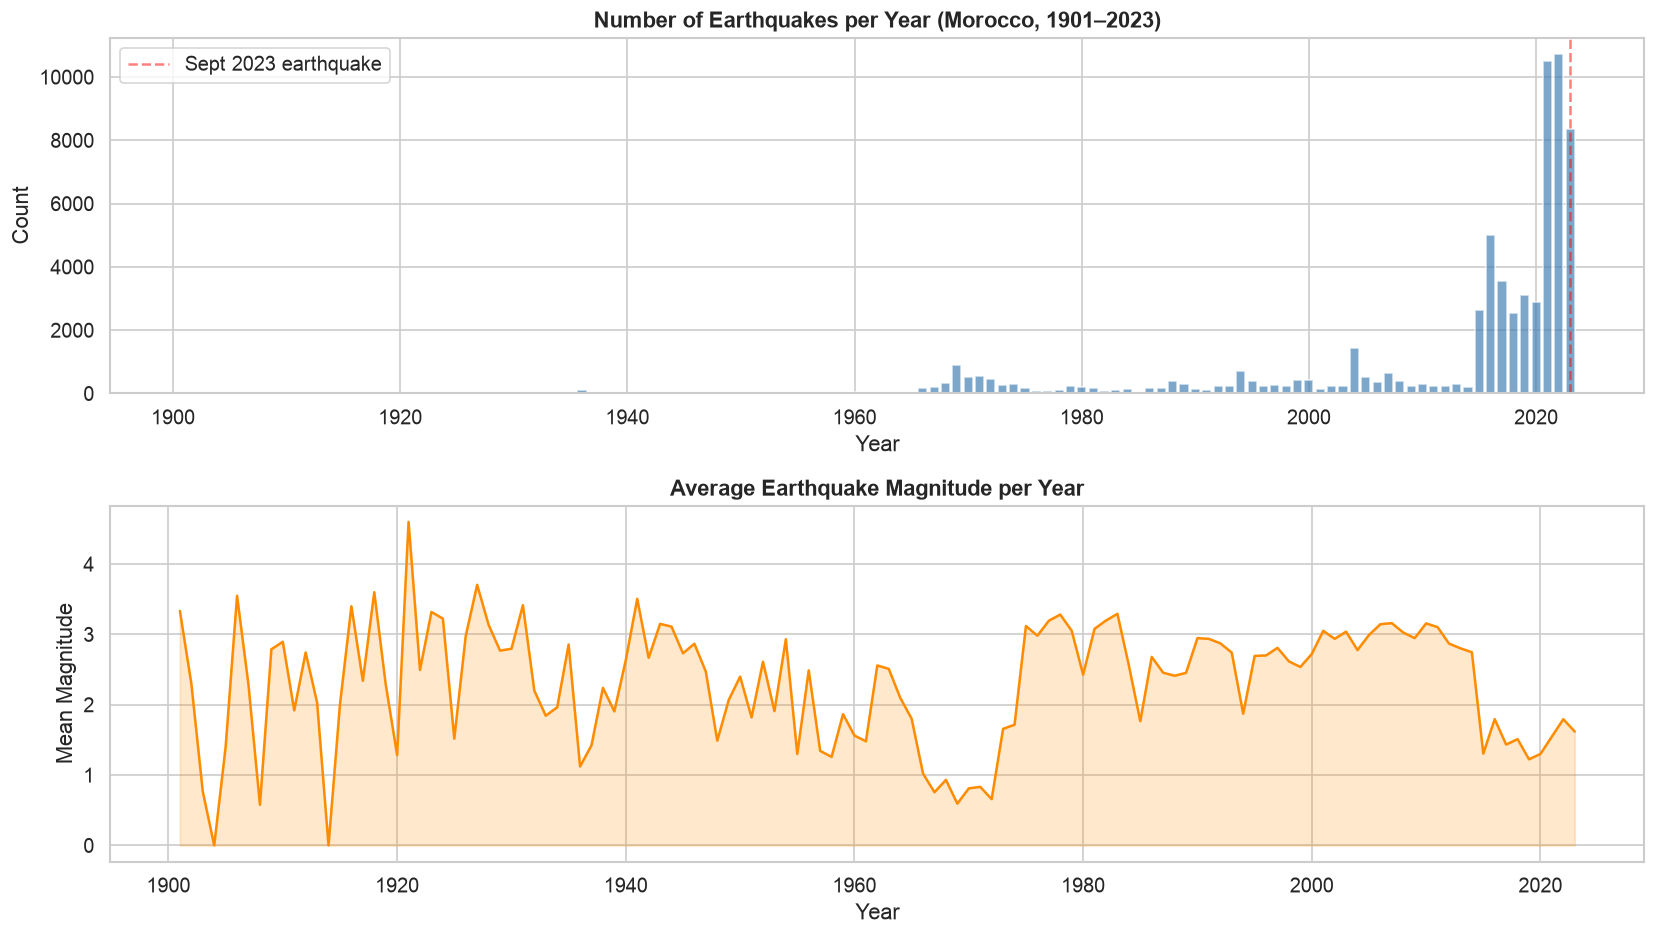

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Earthquake count per year
yearly_count = df.groupby('year').size()
axes[0].bar(yearly_count.index, yearly_count.values, color='steelblue', alpha=0.7, width=0.8)
axes[0].set_title('Number of Earthquakes per Year (Morocco, 1901–2023)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Count')
axes[0].axvline(2023, color='red', linestyle='--', alpha=0.5, label='Sept 2023 earthquake')
axes[0].legend()

# Average magnitude per year
yearly_mag = df.groupby('year')['mag'].mean()
axes[1].plot(yearly_mag.index, yearly_mag.values, color='darkorange', linewidth=1.5)
axes[1].fill_between(yearly_mag.index, yearly_mag.values, alpha=0.2, color='darkorange')
axes[1].set_title('Average Earthquake Magnitude per Year', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Mean Magnitude')

plt.tight_layout()
plt.savefig(FIGURES + 'temporal_trends.png', bbox_inches='tight')
plt.show()

## 5. Magnitude Distribution

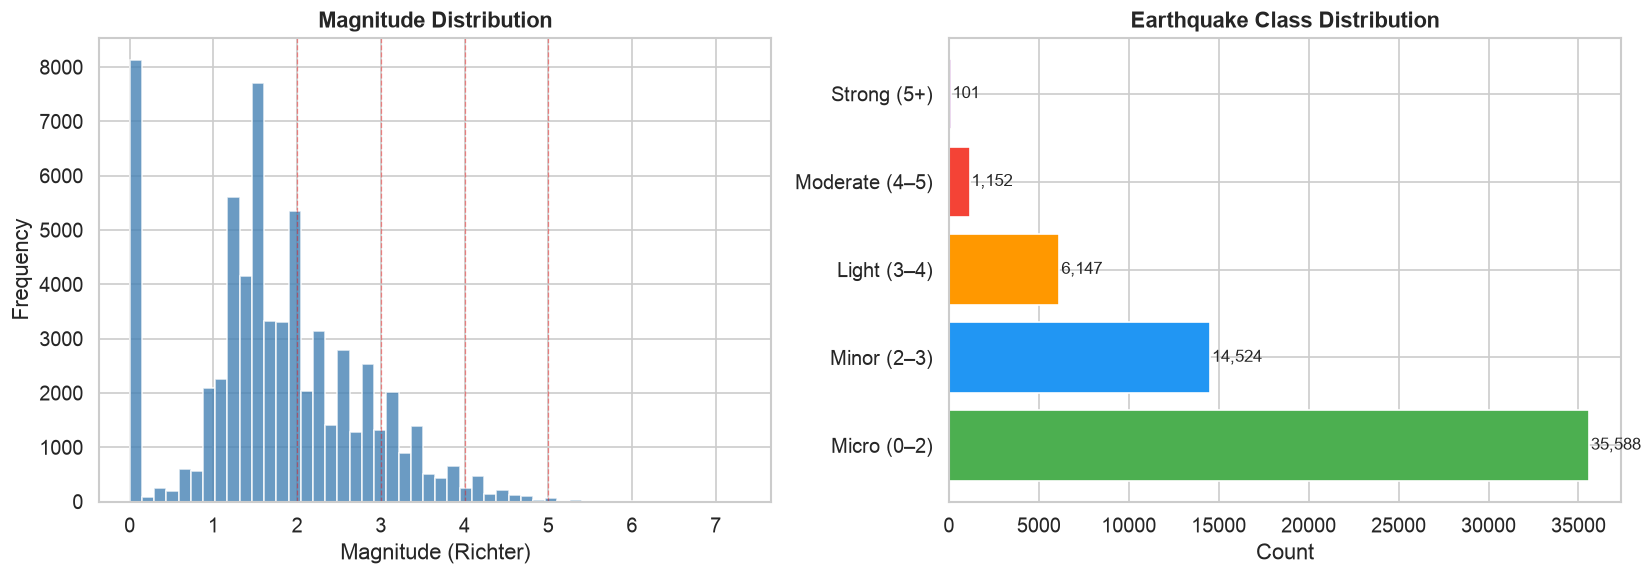


Class distribution:
                count   pct
mag_class                  
Micro (0–2)     35588  54.3
Minor (2–3)     14524  22.1
Light (3–4)      6147   9.4
Moderate (4–5)   1152   1.8
Strong (5+)       101   0.2


In [6]:
bins   = [0, 2, 3, 4, 5, 10]
labels = ['Micro (0–2)', 'Minor (2–3)', 'Light (3–4)', 'Moderate (4–5)', 'Strong (5+)']
df['mag_class'] = pd.cut(df['mag'], bins=bins, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['mag'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Magnitude Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Magnitude (Richter)')
axes[0].set_ylabel('Frequency')
for b in bins[1:-1]:
    axes[0].axvline(b, color='red', linestyle='--', alpha=0.4, linewidth=0.8)

# Class counts
class_counts = df['mag_class'].value_counts().sort_index()
colors = ['#4CAF50','#2196F3','#FF9800','#F44336','#9C27B0']
axes[1].barh(class_counts.index, class_counts.values, color=colors, edgecolor='white')
axes[1].set_title('Earthquake Class Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Count')
for i, v in enumerate(class_counts.values):
    axes[1].text(v + 100, i, f'{v:,}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(FIGURES + 'magnitude_distribution.png', bbox_inches='tight')
plt.show()

print('\nClass distribution:')
print(class_counts.to_frame('count').assign(pct=lambda x: (x['count']/len(df)*100).round(1)))

## 6. Spatial Distribution

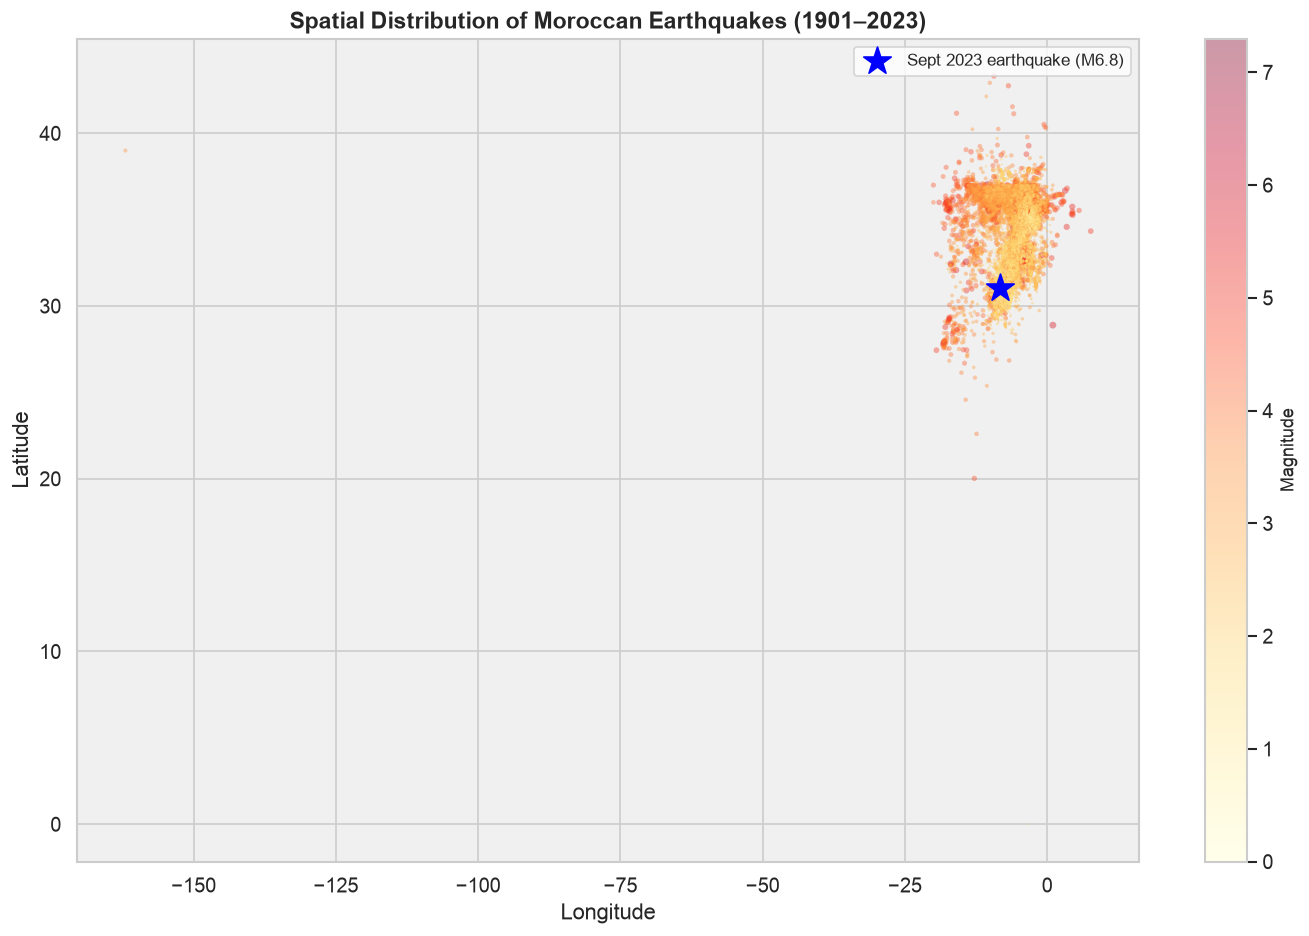

In [7]:
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(
    df['longitude'], df['latitude'],
    c=df['mag'], cmap='YlOrRd',
    s=df['mag']**2 * 0.5,
    alpha=0.4, linewidths=0
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Magnitude', fontsize=11)

# Highlight September 2023 earthquake (Al Haouz, 6.8 Mw)
ax.scatter(-8.38, 31.07, color='blue', s=300, marker='*',
           zorder=5, label='Sept 2023 earthquake (M6.8)')

ax.set_title('Spatial Distribution of Moroccan Earthquakes (1901–2023)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(fontsize=10)
ax.set_facecolor('#f0f0f0')

plt.tight_layout()
plt.savefig(FIGURES + 'spatial_distribution.png', bbox_inches='tight')
plt.show()

## 7. Depth Analysis

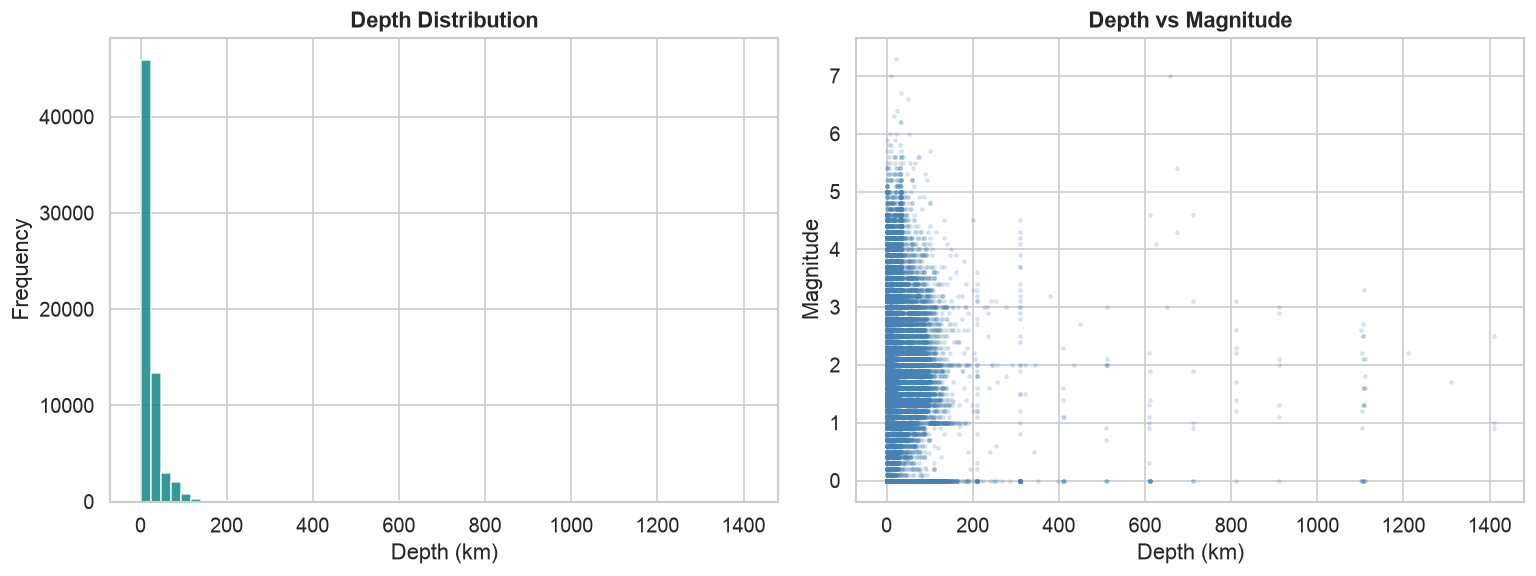

Shallow (<70 km):    62,134 (94.7%)
Intermediate (70–300): 3,296
Deep (>300 km):      148


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df['depth'], bins=60, color='teal', edgecolor='white', alpha=0.8)
axes[0].set_title('Depth Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Depth (km)')
axes[0].set_ylabel('Frequency')

axes[1].scatter(df['depth'], df['mag'], alpha=0.15, s=4, color='steelblue')
axes[1].set_title('Depth vs Magnitude', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Depth (km)')
axes[1].set_ylabel('Magnitude')

plt.tight_layout()
plt.savefig(FIGURES + 'depth_analysis.png', bbox_inches='tight')
plt.show()

print(f"Shallow (<70 km):    {(df['depth']<70).sum():,} ({(df['depth']<70).mean()*100:.1f}%)")
print(f"Intermediate (70–300): {df['depth'].between(70,300).sum():,}")
print(f"Deep (>300 km):      {(df['depth']>300).sum():,}")

## 8. Correlation Analysis

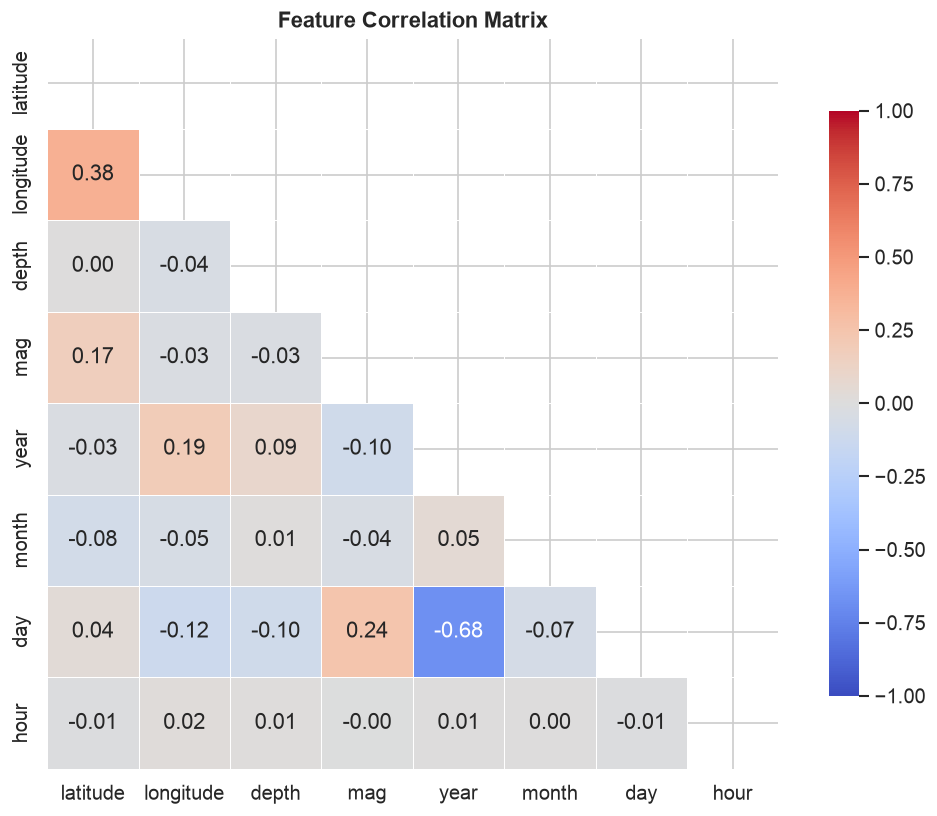

In [9]:
corr_cols = ['latitude','longitude','depth','mag','year','month','day','hour']
corr = df[corr_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, center=0, ax=ax,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES + 'correlation_matrix.png', bbox_inches='tight')
plt.show()

## 9. Summary

| Metric | Value |
|--------|-------|
| Records (raw) | 65,931 |
| Records (clean) | 65,578 |
| Time span | 1901–2023 |
| Magnitude range | 0.0 – 7.3 |
| Dominant class | Micro (0–2): 54.3% |
| Shallow earthquakes (<70 km) | ~87% of dataset |

The dataset is heavily imbalanced toward low-magnitude events, which is physically expected (Gutenberg-Richter law). This imbalance is a key challenge for the classification models in `02_model_comparison.ipynb`.